# cfdb starter analysis

A working notebook against the **serving layer** — the `srv_*` views dbt builds into the
`serving` schema. They are denormalized and pre-joined, one row per stated grain, which is
what makes them the right thing to analyse: no joins are needed to get a usable frame, and
every metric on them already carries the project's definition.

Two files do the setup so the cells below can be about football:

| File | What it holds |
|---|---|
| [`cfdb_conn.py`](cfdb_conn.py) | connection config, the query helper, schema discovery |
| [`cfdb_plots.py`](cfdb_plots.py) | the chart builders and the validated palette |

## Before the first run

The notebook reads the **droplet's serving Postgres** — the production warehouse — through
an SSH tunnel. Postgres is not published to the droplet's host; it exists only on the
Docker network, so the forward targets a container address:

```bash
# Terminal 1. Prints nothing and stays running — a silent terminal is the success case.
ssh -N -L 15432:172.19.0.2:5432 root@<droplet>
```

`cf.tunnel_command()` prints that line filled in from your `.env`, so you never have to
remember the container IP.

With the tunnel up, the notebook needs nothing else: `CFDB_NOTEBOOK_BACKEND=remote` is the
default, and `.env` (gitignored) carries the droplet address. The other two backends are a
variable away:

| `CFDB_NOTEBOOK_BACKEND` | Reads |
|---|---|
| `remote` *(default)* | the droplet's serving Postgres, through the tunnel |
| `postgres` | a local transform warehouse from `docker compose up -d postgres` |
| `databricks` | the transform warehouse in Unity Catalog |

**Check the freshness stamp before trusting a number.** A stale warehouse answers every
query without complaining — that is the failure mode a notebook cannot see, which is why
`cf.check()` prints how old the data is and `cf.freshness()` breaks it down per domain.

## Two rules worth knowing up front

**Metrics belong in dbt, not here.** A number you compute in this notebook is a number the
site cannot show. If an analysis below turns into something worth publishing, the next step
is a dbt model, not a copy of the cell.

**The site's one-table rule does not bind you.** `site/db.py` is held to a single `srv_*`
table per query because a Streamlit page must not define metrics. A notebook is
exploration — join freely.

## Setup

In [17]:
# Both helpers live beside this notebook, so no path juggling is needed.
import cfdb_conn as cf
import cfdb_plots as viz

import pandas as pd

viz.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

In [18]:
# What am I actually connected to? Prints the target and proves it with a live query.
cf.check()

repo root : /Users/marcalexander/ncaa_football_2nd/ncaa_football
backend   : postgres
target    : cfdb@localhost:5432/cfdb
schema    : serving
connected : yes -- 28 srv_ views visible


In [ ]:
# Per-domain, because the domains legitimately disagree: a lines snapshot
# refreshes every few hours and a 1936 poll never does.
cf.freshness()


## What is in the serving layer

Start here rather than from a list of table names in your head — the layer grows, and this
is the version of it that exists today.

In [19]:
cf.tables()

,table_name,approx_rows
0,srv_data_dictionary,1296
1,srv_edge_bucket_performance,-1
2,srv_edge_finder,3366
3,srv_game,110879
4,srv_game_travel,221758
5,srv_game_weather,6463
6,srv_line_movement,15231
7,srv_matchup,110879
8,srv_model_performance,193
9,srv_odds_board,6656


`srv_data_dictionary` is the warehouse cataloguing itself: one row per modelled column,
with the description dbt persisted from `schema.yml`. It is the same catalogue the site's
Data Dictionary page renders, so it is the authority on what a column means.

(It is built in a second pass after everything else, so on a fresh warehouse it can lag by
one run. `cf.columns()` reads the live catalogue if you need certainty.)

In [20]:
cf.dictionary("srv_team_game_log")[["column_name", "data_type", "column_description"]]

,column_name,data_type,column_description
0,game_team_sk,text,None
1,team_game_key,text,None
2,season,integer,None
3,week,integer,None
4,season_type,text,None
5,game_id,integer,None
6,team_id,integer,None
7,team,text,None
8,conference,text,None
9,classification,text,None


In [21]:
# The live alternative, straight from the database catalogue.
cf.columns("srv_standings").head(30)

,column_name,data_type,is_nullable,description
0,team_season_sk,text,True,"Surrogate key over (season, team) — the grain."
1,team_season_key,text,True,"Readable composite key, `season-team_id`. Reta..."
2,season,integer,True,Season the record covers.
3,team_id,integer,True,CFBD team id.
4,is_listed_team,boolean,True,Whether the team appears in CFBD's own team li...
5,school,text,True,School name.
6,conference,text,True,Conference affiliation for that season.
7,classification,text,True,Division for that season.
8,games_played,bigint,True,Games played that season.
9,wins,bigint,True,Wins that season.


In [22]:
# Shape check: five rows, no ordering claimed.
cf.peek("srv_standings", n=5)

,team_season_sk,team_season_key,season,team_id,is_listed_team,school,conference,classification,games_played,wins,losses,ties,points_for,points_against,point_differential,win_pct,conference_wins,conference_losses,tiebreak_rank,tiebreak_basis,color_on_light,color_on_dark,logo_source_url,abbreviation,as_of_ts,team_slug,team_display,logo_url,division,conference_win_pct,home_wins,home_losses,away_wins,away_losses,neutral_games,home_record_display,away_record_display,current_streak_display,current_streak_outcome,current_streak_length,last_5_display,ats_record_display,ats_as_favorite_display,ats_as_underdog_display
0,33982571c0bb8d74ab2029172d58a533,1874-164,1874,164,True,Rutgers,FBS Independents,fbs,4,1,3,0,7,17,-10,0.25,0,0,3,"conference_win_pct,overall_win_pct,point_diffe...",#ce0e2d,#ce0e2d,https://cdn.collegefootballdata.com/logos/500/...,RUTG,2026-08-30 12:01:49.451758+00:00,rutgers,Rutgers,https://cdn.collegefootballdata.com/logos/500/...,None,None,1,1,0,2,0,1-1,0-2,L3,L,3,1-3,None,None,None
1,3e0c7f7074311988398100374d16143c,1869-163,1869,163,True,Princeton,FBS Independents,fbs,2,1,1,0,12,6,6,0.50,0,0,1,"conference_win_pct,overall_win_pct,point_diffe...",#000000,#ff6000,https://cdn.collegefootballdata.com/logos/500/...,PRIN,2026-08-30 12:01:49.451758+00:00,princeton,Princeton,https://cdn.collegefootballdata.com/logos/500/...,None,None,1,0,0,1,0,1-0,0-1,W1,W,1,1-1,None,None,None
2,83ada7cfe796050a3aee0406de64bd00,1869-164,1869,164,True,Rutgers,FBS Independents,fbs,2,1,1,0,6,12,-6,0.50,0,0,2,"conference_win_pct,overall_win_pct,point_diffe...",#ce0e2d,#ce0e2d,https://cdn.collegefootballdata.com/logos/500/...,RUTG,2026-08-30 12:01:49.451758+00:00,rutgers,Rutgers,https://cdn.collegefootballdata.com/logos/500/...,None,None,1,0,0,1,0,1-0,0-1,L1,L,1,1-1,None,None,None
3,7bf6fb682c4cfa28bb039653c44d6471,1870-163,1870,163,True,Princeton,FBS Independents,fbs,1,1,0,0,6,2,4,1.00,0,0,1,"conference_win_pct,overall_win_pct,point_diffe...",#000000,#ff6000,https://cdn.collegefootballdata.com/logos/500/...,PRIN,2026-08-30 12:01:49.451758+00:00,princeton,Princeton,https://cdn.collegefootballdata.com/logos/500/...,None,None,1,0,0,0,0,1-0,None,W1,W,1,1-0,None,None,None
4,e8121104abb2470c808f7dbf2d5dc33c,1870-164,1870,164,True,Rutgers,FBS Independents,fbs,2,1,1,0,8,9,-1,0.50,0,0,2,"conference_win_pct,overall_win_pct,point_diffe...",#ce0e2d,#ce0e2d,https://cdn.collegefootballdata.com/logos/500/...,RUTG,2026-08-30 12:01:49.451758+00:00,rutgers,Rutgers,https://cdn.collegefootballdata.com/logos/500/...,None,None,1,0,0,1,0,1-0,0-1,L1,L,1,1-1,None,None,None


## Pick a season

Derived from the data rather than typed in. The current season exists in the warehouse as
soon as the schedule does — framework data lands before Week 1 — so "the newest season" and
"the newest season with completed games" are different questions, and for a retrospective
it is the second one you want.

In [23]:
seasons = cf.q(f"""
    select season,
           count(*) as team_games,
           sum(case when is_completed then 1 else 0 end) as completed
    from {cf.t("srv_team_game_log")}
    where classification = 'fbs'
    group by season
    order by season desc
""", limit=None).head(8)

SEASON = int(seasons.loc[seasons["completed"] > 100, "season"].max())
print(f"analysing season {SEASON}")
seasons

analysing season 2025


,season,team_games,completed
0,2026,1649,16
1,2025,1742,1742
2,2024,1719,1717
3,2023,1702,1702
4,2022,1672,1672
5,2021,1657,1657
6,2020,1104,1104
7,2019,1662,1662


## 1. Which conferences outscored their opponents?

One row per team-game in `srv_team_game_log`, so a conference average here is the average
margin of its members' games — including the non-conference ones, which is the point: it
measures the league against everyone it played, not against itself.

`classification = 'fbs'` is doing real work. The serving layer carries non-FBS opponents as
stubs so that an FBS team's schedule is complete; without the filter you would be averaging
in teams the project holds no deep data for.

In [24]:
conf = cf.q(f"""
    select conference,
           count(*)    as team_games,
           avg(margin) as avg_margin
    from {cf.t("srv_team_game_log")}
    where season = :season
      and is_completed
      and classification = 'fbs'
      and conference is not null
    group by conference
    order by avg_margin desc
""", {"season": SEASON}, limit=None)

conf["avg_margin"] = conf["avg_margin"].round(2)
conf

,conference,team_games,avg_margin
0,FBS Independents,25,16.04
1,SEC,208,7.53
2,Big Ten,234,6.25
3,Big 12,202,4.51
4,ACC,220,3.26
5,American Athletic,179,1.46
6,Mountain West,153,0.62
7,Sun Belt,180,-1.33
8,Conference USA,153,-2.40
9,Mid-American,163,-2.95


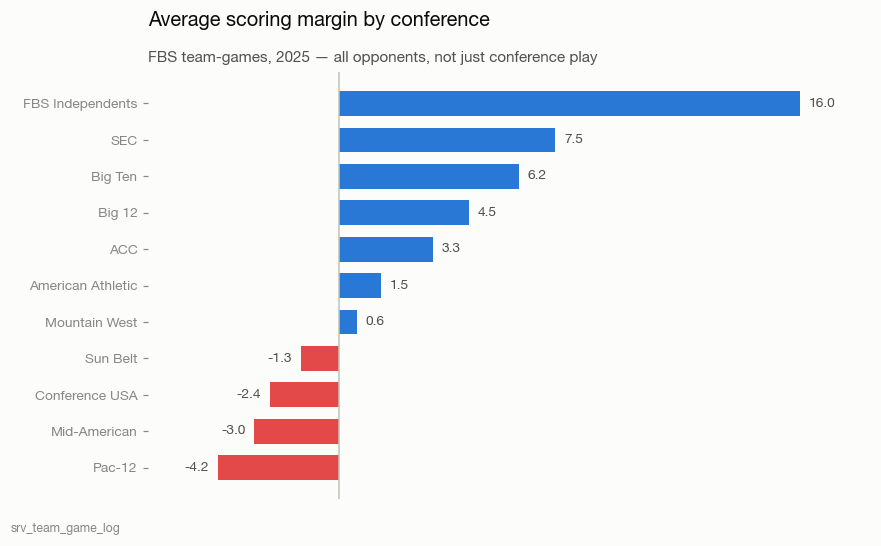

In [25]:
fig, ax = viz.bar(
    conf, "conference", "avg_margin",
    diverging=True,              # zero means something here, so color carries the sign
    title="Average scoring margin by conference",
    subtitle=f"FBS team-games, {SEASON} — all opponents, not just conference play",
    source="srv_team_game_log",
)

## 2. The shape of a season

The game log is small enough at FBS-and-one-season to pull whole and slice in pandas, which
is usually the right move for exploration: one query, many questions.

In [26]:
games = cf.q(f"""
    select season, week, team, conference, opponent, venue_role,
           is_conference_game, points_for, points_against, margin, result,
           total_yards, turnovers, attendance
    from {cf.t("srv_team_game_log")}
    where season = :season
      and is_completed
      and classification = 'fbs'
    order by team, week
""", {"season": SEASON}, limit=25_000)

print(f"{len(games):,} team-games, {games['team'].nunique()} teams")
games.head()

1,742 team-games, 136 teams


,season,week,team,conference,opponent,venue_role,is_conference_game,points_for,points_against,margin,result,total_yards,turnovers,attendance
0,2025,1,Air Force,Mountain West,Bucknell,home,False,49,13,36,W,426,0,30207.0
1,2025,3,Air Force,Mountain West,Utah State,away,True,30,49,-19,L,445,3,17124.0
2,2025,4,Air Force,Mountain West,Boise State,home,True,37,49,-12,L,515,1,24046.0
3,2025,5,Air Force,Mountain West,Hawai'i,home,True,35,44,-9,L,494,1,22677.0
4,2025,6,Air Force,Mountain West,Navy,away,False,31,34,-3,L,460,1,37517.0


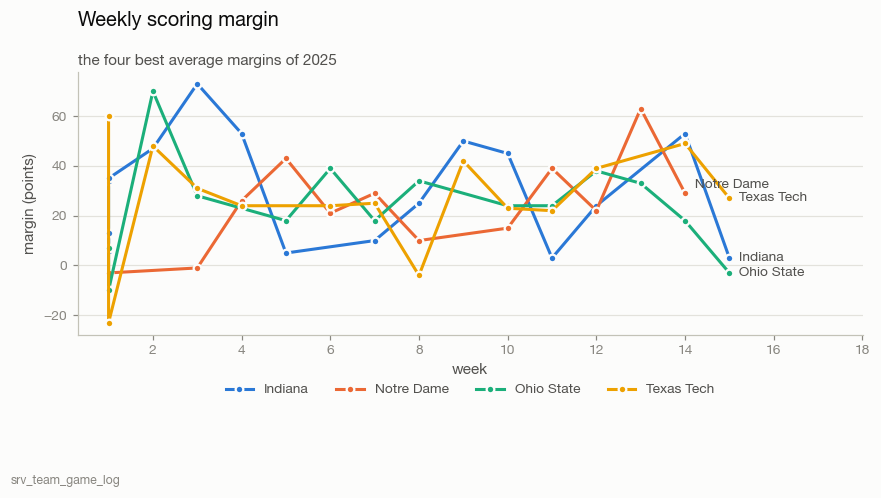

In [27]:
# Four teams, chosen by the data rather than by preference.
best = (games.groupby("team")["margin"].mean()
        .sort_values(ascending=False).head(4).index.tolist())

fig, ax = viz.line(
    games[games["team"].isin(best)], "week", "margin", series="team",
    title="Weekly scoring margin",
    subtitle=f"the four best average margins of {SEASON}",
    xlabel="week", ylabel="margin (points)",
    source="srv_team_game_log",
)

## 3. Offence against defence

`srv_standings` is one row per team-season, so it is the natural frame for a season-level
scatter. The diagonal is where a team scored exactly as many points as it allowed; below it
is a positive point differential.

Only the extremes are labeled. Labelling all 130-odd teams would make the chart unreadable
and tell you nothing the table does not.

In [28]:
standings = cf.q(f"""
    select school, conference, games_played, wins, losses,
           points_for, points_against, point_differential, win_pct
    from {cf.t("srv_standings")}
    where season = :season
      and classification = 'fbs'
      and games_played > 0
""", {"season": SEASON}, limit=None)

standings.sort_values("point_differential", ascending=False).head(10)

,school,conference,games_played,wins,losses,points_for,points_against,point_differential,win_pct
47,Indiana,Big Ten,16,16,0,666,187,479,1.000
31,Texas Tech,Big 12,14,12,2,552,165,387,0.857
48,Ohio State,Big Ten,14,12,2,468,130,338,0.857
77,Notre Dame,FBS Independents,12,10,2,504,211,293,0.833
33,Utah,Big 12,13,11,2,537,246,291,0.846
49,Oregon,Big Ten,15,13,2,554,268,286,0.867
122,James Madison,Sun Belt,14,12,2,519,257,262,0.857
18,North Texas,American Athletic,14,12,2,631,371,260,0.857
1,Miami,ACC,16,13,3,495,237,258,0.813
106,Ole Miss,SEC,15,13,2,554,316,238,0.867


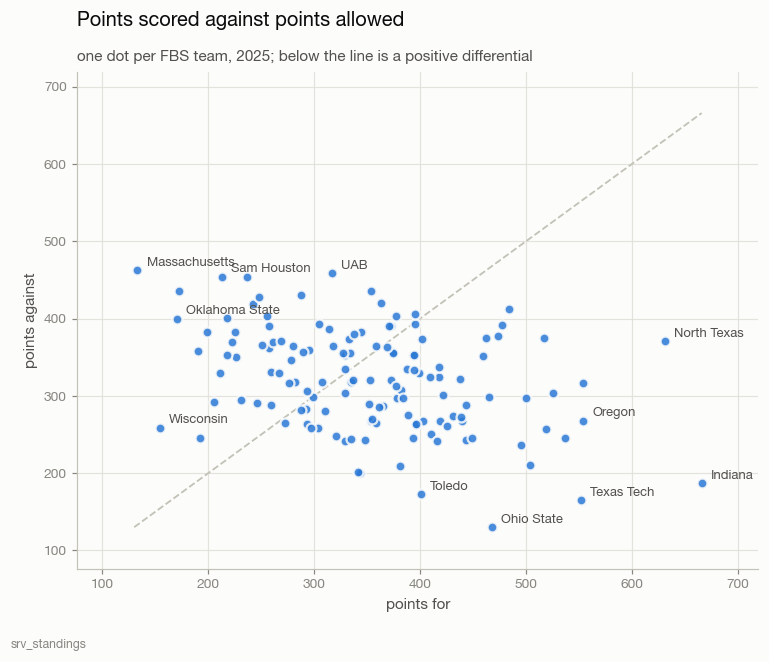

In [29]:
fig, ax = viz.scatter(
    standings, "points_for", "points_against",
    label="school", label_n=3, reference_line=True,
    title="Points scored against points allowed",
    subtitle=f"one dot per FBS team, {SEASON}; below the line is a positive differential",
    xlabel="points for", ylabel="points against",
    source="srv_standings",
)

## 4. How lopsided is a college football game?

Every game appears twice in the team game log — once from each side — so the margin
distribution over all rows is symmetric around zero by construction, and tells you nothing.
Filtering to the home row gives one row per game and turns the same column into a reading
of home-field advantage.

Neutral-site games are excluded rather than counted as home, which is why the count below
falls short of the full slate.

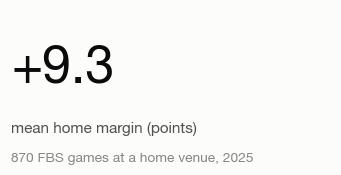

In [30]:
home = games[games["venue_role"] == "home"]

fig, ax = viz.stat(
    f"{home['margin'].mean():+.1f}",
    "mean home margin (points)",
    context=f"{len(home):,} FBS games at a home venue, {SEASON}",
)

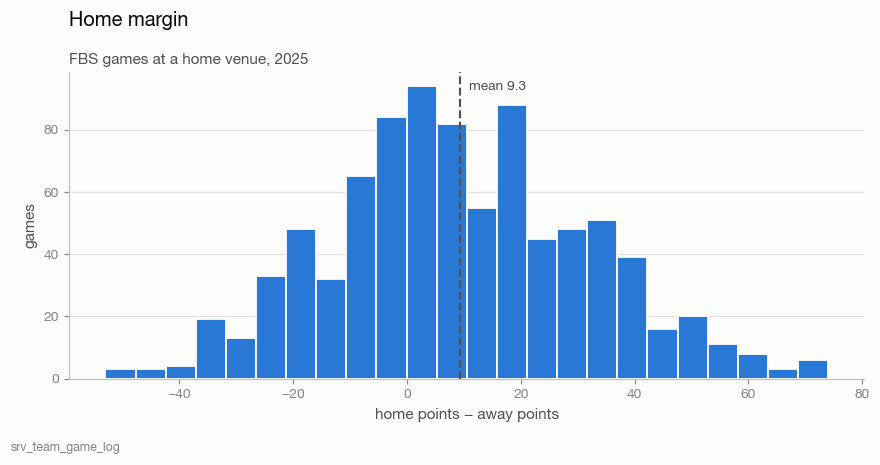

In [31]:
fig, ax = viz.dist(
    home["margin"], bins=24,
    title="Home margin",
    subtitle=f"FBS games at a home venue, {SEASON}",
    xlabel="home points − away points", ylabel="games",
    source="srv_team_game_log",
)

In [32]:
# Home advantage split by whether it was a conference game.
split = (home.assign(kind=home["is_conference_game"].map({True: "Conference",
                                                          False: "Non-conference"}))
         .groupby("kind")
         .agg(games=("margin", "size"),
              mean_margin=("margin", "mean"),
              home_win_pct=("result", lambda s: (s == "W").mean()))
         .reset_index()
         .round(3))
split

,kind,games,mean_margin,home_win_pct
0,Conference,537,2.708,0.553
1,Non-conference,333,19.991,0.808


## Where to go next

Other views worth opening — run `cf.dictionary("<name>")` on any of them first:

| View | Grain | Good for |
|---|---|---|
| `srv_game` | one row per game | schedule, scores, the market line, model predictions |
| `srv_game_team` | one row per game-team | against-the-spread work, line-implied points |
| `srv_odds_board` | game × provider | comparing books, best available number |
| `srv_line_movement` | line snapshots | how a number moved between open and close |
| `srv_team_rating` | team × week | ratings over a season |
| `srv_player_game_log` | player × game | box-score work |
| `srv_rankings` | poll × week × team | poll history, back to the 1930s |
| `srv_edge_finder` | game | where the model and the market disagree |

Two reminders as you go:

**Depth is not uniform, and that is by design.** Play-by-play, drives, lines and box scores
are 2024 onward; games, records, rankings, teams and coaches go back as far as the API
serves them. `src/endpoints.py` is the source of truth for which is which — a query that
returns nothing for 1998 is usually asking a shallow endpoint a deep question.

**Anything worth keeping becomes a dbt model.** A metric defined in this notebook exists
only here: the site cannot render it, no test guards it, and the next notebook will define
it slightly differently. When an analysis is worth repeating, move it to `dbt/models/` and
let the serving layer hand it back.